In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objs as go

random_s = 101

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/personnel_data.csv')
df.head()

,EmployeeID,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
0,1,50,1,2,33.07,3,5,10,0
1,2,36,4,1,19.37,7,1,11,0
2,3,29,28,1,52.64,8,1,5,1
3,4,42,18,3,60.37,10,4,8,0
4,5,40,7,1,28.94,6,3,15,0


In [ ]:
cleaned_data = df.drop(columns=['EmployeeID', 'Department'])
cleaned_data.head()

,Age,Experience,EducationLevel,Salary,JobSatisfaction,ProjectsHandled,PromotionLast5Years
0,50,1,2,33.07,3,10,0
1,36,4,1,19.37,7,11,0
2,29,28,1,52.64,8,5,1
3,42,18,3,60.37,10,8,0
4,40,7,1,28.94,6,15,0


In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cleaned_data)
scaled_data = pd.DataFrame(scaled_data, columns=cleaned_data.columns)

In [ ]:
# Correlation analysis and dimensionality reduction
correlation_matrix = cleaned_data.corr()

# Find highly correlated pairs (absolute value > 0.66)
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.66:
            high_corr.append((correlation_matrix.columns[i], correlation_matrix.columns[j],
                            correlation_matrix.iloc[i, j]))

# Display highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.66):")
for pair in high_corr:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.2f}")

# Determine which variables to eliminate (alphabetical order)
variables_to_eliminate = set()
for pair in high_corr:
    if pair[0] < pair[1]:
        variables_to_eliminate.add(pair[0])
    else:
        variables_to_eliminate.add(pair[1])

print(f"\n4. Variables to eliminate: {sorted(variables_to_eliminate)}")



Highly correlated pairs (|r| > 0.66):
Experience - Salary: 0.69

4. Variables to eliminate: ['Experience']


In [ ]:
# Reduce dimensions
reduced_data = cleaned_data.drop(columns=sorted(variables_to_eliminate))
print(f"Remaining features: {list(reduced_data.columns)}")

# Scale the reduced data
reduced_scaled = scaler.fit_transform(reduced_data)
reduced_scaled = pd.DataFrame(reduced_scaled, columns=reduced_data.columns)

Remaining features: ['Age', 'EducationLevel', 'Salary', 'JobSatisfaction', 'ProjectsHandled', 'PromotionLast5Years']


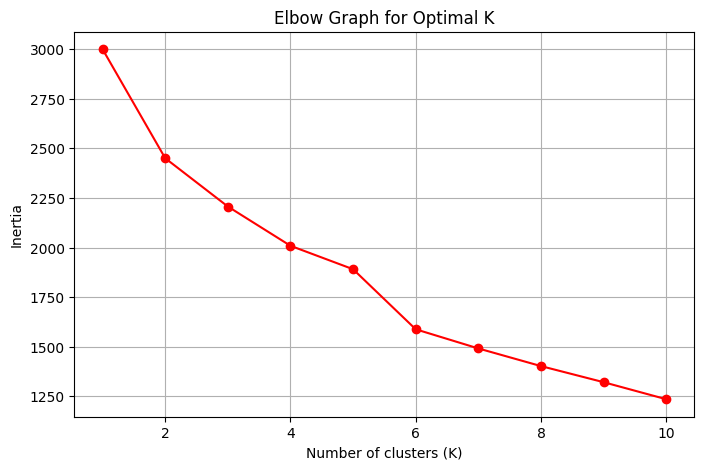

In [ ]:
# Elbow method for optimal K
inertia = []
K = range(1, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=random_s, n_init='auto')
    model.fit(reduced_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'ro-')
plt.title('Elbow Graph for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [ ]:
# K-Means Clustering

optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=random_s, n_init='auto')
clusters = kmeans.fit_predict(reduced_scaled)

cleaned_data['Cluster'] = clusters

In [ ]:
# Cluster for data 305
cluster_305 = clusters[304]
print(f"Data 305 belongs to cluster: {cluster_305}")

Data 305 belongs to cluster: 1


In [ ]:
# Centroids of Age and Salary
all_features_data = cleaned_data.drop(columns=['Cluster'])
scaler_all = StandardScaler()
scaled_all = scaler_all.fit_transform(all_features_data)

kmeans_all = KMeans(n_clusters=optimal_k, random_state=random_s, n_init='auto')
kmeans_all.fit(scaled_all)
centroids_scaled = kmeans_all.cluster_centers_
centroids_original = scaler_all.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=all_features_data.columns)

print("9. Centroids of Age and Salary:")
for i in range(optimal_k):
    age_centroid = centroids_df.loc[i, 'Age']
    salary_centroid = centroids_df.loc[i, 'Salary']
    print(f"Cluster {i}: [{age_centroid:.2f}, {salary_centroid:.2f}]")

9. Centroids of Age and Salary:
Cluster 0: [40.39, 69.22]
Cluster 1: [42.08, 39.94]


In [ ]:
# Correlational Analysis
correlation_matrix = scaled_data.corr()
correlation_matrix

,Age,Experience,EducationLevel,Salary,JobSatisfaction,ProjectsHandled,PromotionLast5Years
Age,1.000000,-0.009887,-0.073172,-0.057021,-0.048376,0.059960,-0.026902
Experience,-0.009887,1.000000,-0.041060,0.686259,-0.009742,0.003324,-0.020027
EducationLevel,-0.073172,-0.041060,1.000000,0.645446,0.033241,0.006041,0.002954
Salary,-0.057021,0.686259,0.645446,1.000000,-0.009889,0.009303,-0.009194
JobSatisfaction,-0.048376,-0.009742,0.033241,-0.009889,1.000000,-0.003085,-0.033296
ProjectsHandled,0.059960,0.003324,0.006041,0.009303,-0.003085,1.000000,-0.007724
PromotionLast5Years,-0.026902,-0.020027,0.002954,-0.009194,-0.033296,-0.007724,1.000000


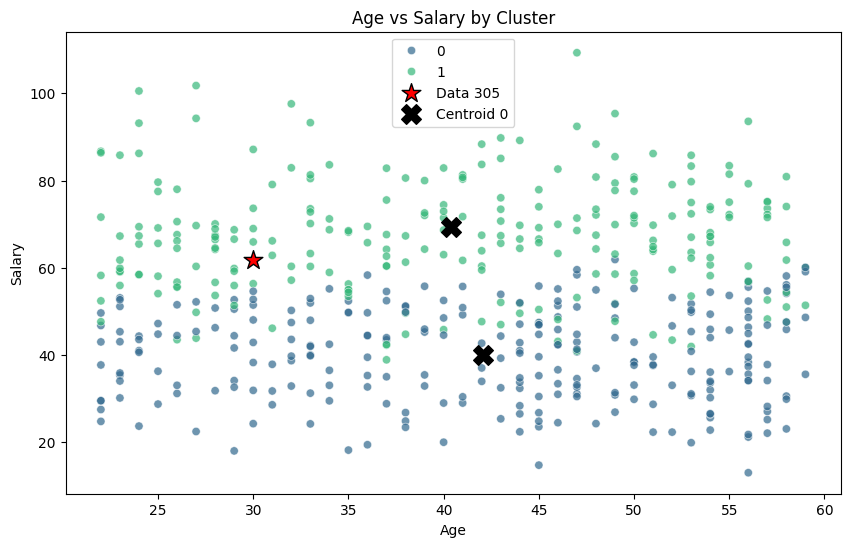

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_data, x='Age', y='Salary', hue='Cluster', palette='viridis', alpha=0.7)

data_305 = cleaned_data.iloc[304]
plt.scatter(data_305['Age'], data_305['Salary'], color='red', marker='*', s=200,
           edgecolor='black', label='Data 305')

# Add centroids
for i in range(optimal_k):
    plt.scatter(centroids_df.loc[i, 'Age'], centroids_df.loc[i, 'Salary'],
               marker='X', s=200, c='black', label=f'Centroid {i}' if i == 0 else "")

plt.title('Age vs Salary by Cluster')
plt.legend()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

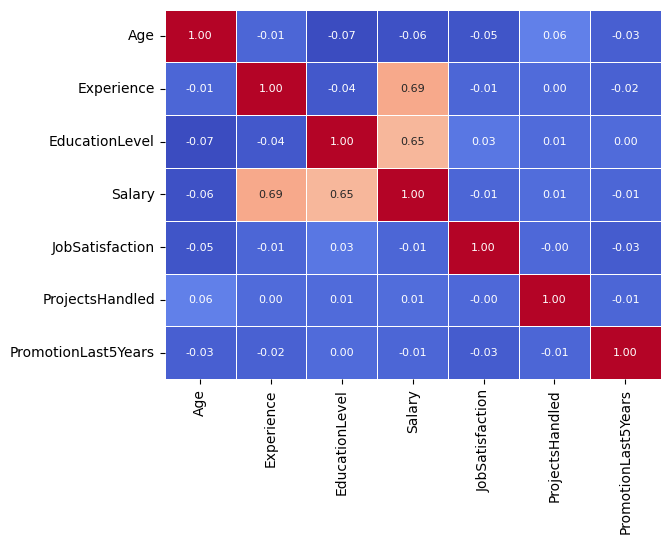

In [ ]:
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', linewidths = 0.5, fmt = '.2f', annot_kws={"size": 8}, cbar = False)
plt.show